In [1]:
# Imports for Classification
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder


In [2]:

# Load the cleaned dataset
ev_data = pd.read_csv('Electric_Vehicle_Population_Cleaned_Data.csv')

# Filter out rows where Base MSRP is 0 or extreme outliers
ev_data_filtered = ev_data[ev_data['Base MSRP'] > 0]

# print((ev_data['Base MSRP'] == 0).value_counts())

#  There is a big diffrence in the we filter the data which leads to Electic Range  becomes the important feature impacting the classification of the BEV and PHEV
# if we don't fileter it in case then you can see very less diffrence and range is not the impactful feature in classification of 2 type of electriv vehicle.

# # Check the data after filtering
print(ev_data.groupby('Electric Vehicle Type')['Electric Range'].mean())
print(ev_data_filtered.groupby('Electric Vehicle Type')['Electric Range'].mean())

Electric Vehicle Type
Battery Electric Vehicle (BEV)            57.918866
Plug-in Hybrid Electric Vehicle (PHEV)    30.984301
Name: Electric Range, dtype: float64
Electric Vehicle Type
Battery Electric Vehicle (BEV)            181.401328
Plug-in Hybrid Electric Vehicle (PHEV)     17.333886
Name: Electric Range, dtype: float64


In [3]:
# Initialize LabelEncoder
le = LabelEncoder()

# Encode 'Electric Vehicle Type' for interaction term
ev_data_filtered['Vehicle Type Encoded'] = le.fit_transform(ev_data_filtered['Electric Vehicle Type'])


C:\Users\sakib\AppData\Local\Temp\ipykernel_11076\2476335089.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ev_data_filtered['Vehicle Type Encoded'] = le.fit_transform(ev_data_filtered['Electric Vehicle Type'])


In [4]:
# Add new features for classification
ev_data_filtered['Log_Base_MSRP'] = np.log2(ev_data_filtered['Base MSRP'])
ev_data_filtered['Range_MSRP_Interaction'] = ev_data_filtered['Electric Range'] * ev_data_filtered['Base MSRP']
ev_data_filtered['Range_Type_Interaction'] = ev_data_filtered['Electric Range'] * ev_data_filtered['Vehicle Type Encoded']

C:\Users\sakib\AppData\Local\Temp\ipykernel_11076\450196231.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ev_data_filtered['Log_Base_MSRP'] = np.log2(ev_data_filtered['Base MSRP'])
C:\Users\sakib\AppData\Local\Temp\ipykernel_11076\450196231.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ev_data_filtered['Range_MSRP_Interaction'] = ev_data_filtered['Electric Range'] * ev_data_filtered['Base MSRP']
C:\Users\sakib\AppData\Local\Temp\ipykernel_11076\450196231.py:4: SettingWithCopyWarning: 
A value is

In [5]:
# For classification, choose relevant features
X_class = ev_data_filtered[['Base MSRP', 'Model Year',  'Electric Range','Clean Alternative Fuel Vehicle (CAFV) Eligibility', 'Electric Utility', 'County', 'Postal Code']]
y_class = ev_data_filtered['Electric Vehicle Type']  # Target for classification

# Encode categorical variables for classification
X_class['Clean Alternative Fuel Vehicle (CAFV) Eligibility'] = le.fit_transform(X_class['Clean Alternative Fuel Vehicle (CAFV) Eligibility'])
X_class['Electric Utility'] = le.fit_transform(X_class['Electric Utility'])
X_class['County'] = le.fit_transform(X_class['County'])
X_class['Electric Utility']


X_class.columns

C:\Users\sakib\AppData\Local\Temp\ipykernel_11076\896193418.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_class['Clean Alternative Fuel Vehicle (CAFV) Eligibility'] = le.fit_transform(X_class['Clean Alternative Fuel Vehicle (CAFV) Eligibility'])
C:\Users\sakib\AppData\Local\Temp\ipykernel_11076\896193418.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_class['Electric Utility'] = le.fit_transform(X_class['Electric Utility'])
C:\Users\sakib\AppData\Local\Temp\ipykernel_11076\896193418.py:8: Sett

Index(['Base MSRP', 'Model Year', 'Electric Range',
       'Clean Alternative Fuel Vehicle (CAFV) Eligibility', 'Electric Utility',
       'County', 'Postal Code'],
      dtype='object')

In [6]:

check = pd.concat([X_class,y_class],axis=1)


for col in check.columns:
    if col != 'Electric Vehicle Type':
        print(col)
        print(check.groupby('Electric Vehicle Type')[col].mean())
        print("===================================================")
        
# Here we tried to find the reason of why the model is showing 100% accuracy. There might be because of the high diffrentiation of BEV and PHEV in category of 
# Electric range , CAFV.  



Base MSRP
Electric Vehicle Type
Battery Electric Vehicle (BEV)            59873.648008
Plug-in Hybrid Electric Vehicle (PHEV)    52399.196355
Name: Base MSRP, dtype: float64
Model Year
Electric Vehicle Type
Battery Electric Vehicle (BEV)            2014.101992
Plug-in Hybrid Electric Vehicle (PHEV)    2018.234466
Name: Model Year, dtype: float64
Electric Range
Electric Vehicle Type
Battery Electric Vehicle (BEV)            181.401328
Plug-in Hybrid Electric Vehicle (PHEV)     17.333886
Name: Electric Range, dtype: float64
Clean Alternative Fuel Vehicle (CAFV) Eligibility
Electric Vehicle Type
Battery Electric Vehicle (BEV)            0.000000
Plug-in Hybrid Electric Vehicle (PHEV)    0.881524
Name: Clean Alternative Fuel Vehicle (CAFV) Eligibility, dtype: float64
Electric Utility
Electric Vehicle Type
Battery Electric Vehicle (BEV)            41.545541
Plug-in Hybrid Electric Vehicle (PHEV)    40.101906
Name: Electric Utility, dtype: float64
County
Electric Vehicle Type
Battery Electri

In [7]:
# Step 3: Split data into training and testing sets for classification (75% training, 25% testing)
X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(X_class, y_class, test_size=0.20, random_state=42)

In [8]:
# Step 4: Build and train Classification model using Decision Tree Classifier
clf = DecisionTreeClassifier(max_depth=2)
clf.fit(X_train_class, y_train_class)

print(clf.classes_)

# Predict and evaluate classification model
y_pred_class = clf.predict(X_test_class)
acc = accuracy_score(y_test_class, y_pred_class)
conf_matrix = confusion_matrix(y_test_class, y_pred_class)

# Results
print(f"Classification Model Accuracy: {acc:.2f}")
print("Confusion Matrix:\n", conf_matrix)

['Battery Electric Vehicle (BEV)' 'Plug-in Hybrid Electric Vehicle (PHEV)']
Classification Model Accuracy: 1.00
Confusion Matrix:
 [[429   0]
 [  0 234]]


In [9]:

# Step 5: Apply 10-Fold Cross-Validation for Classification
kfold = KFold(n_splits=10, shuffle=True, random_state=42)
cv_scores_class = cross_val_score(clf, X_class, y_class, cv=kfold, scoring='accuracy')

# Print cross-validation scores for classification
print(f"Cross-validation accuracy: {cv_scores_class.mean():.2f}")

Cross-validation accuracy: 1.00


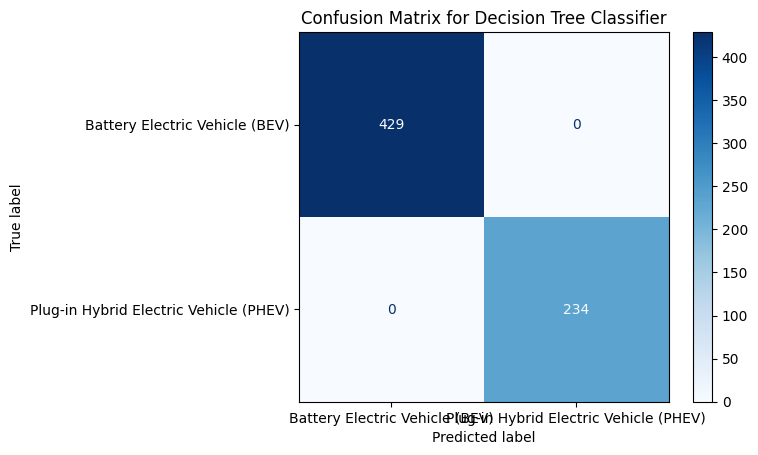

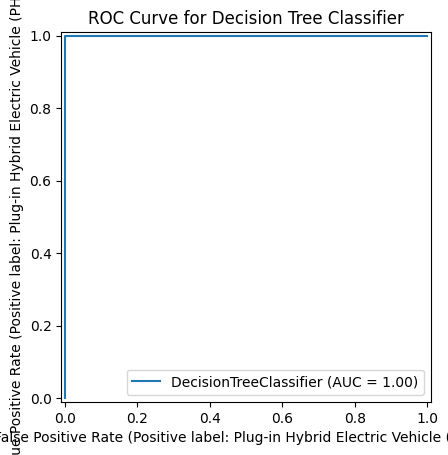

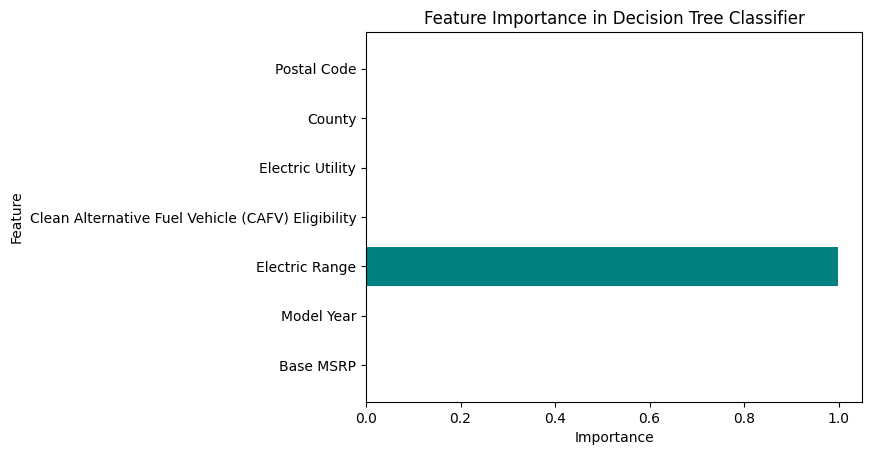

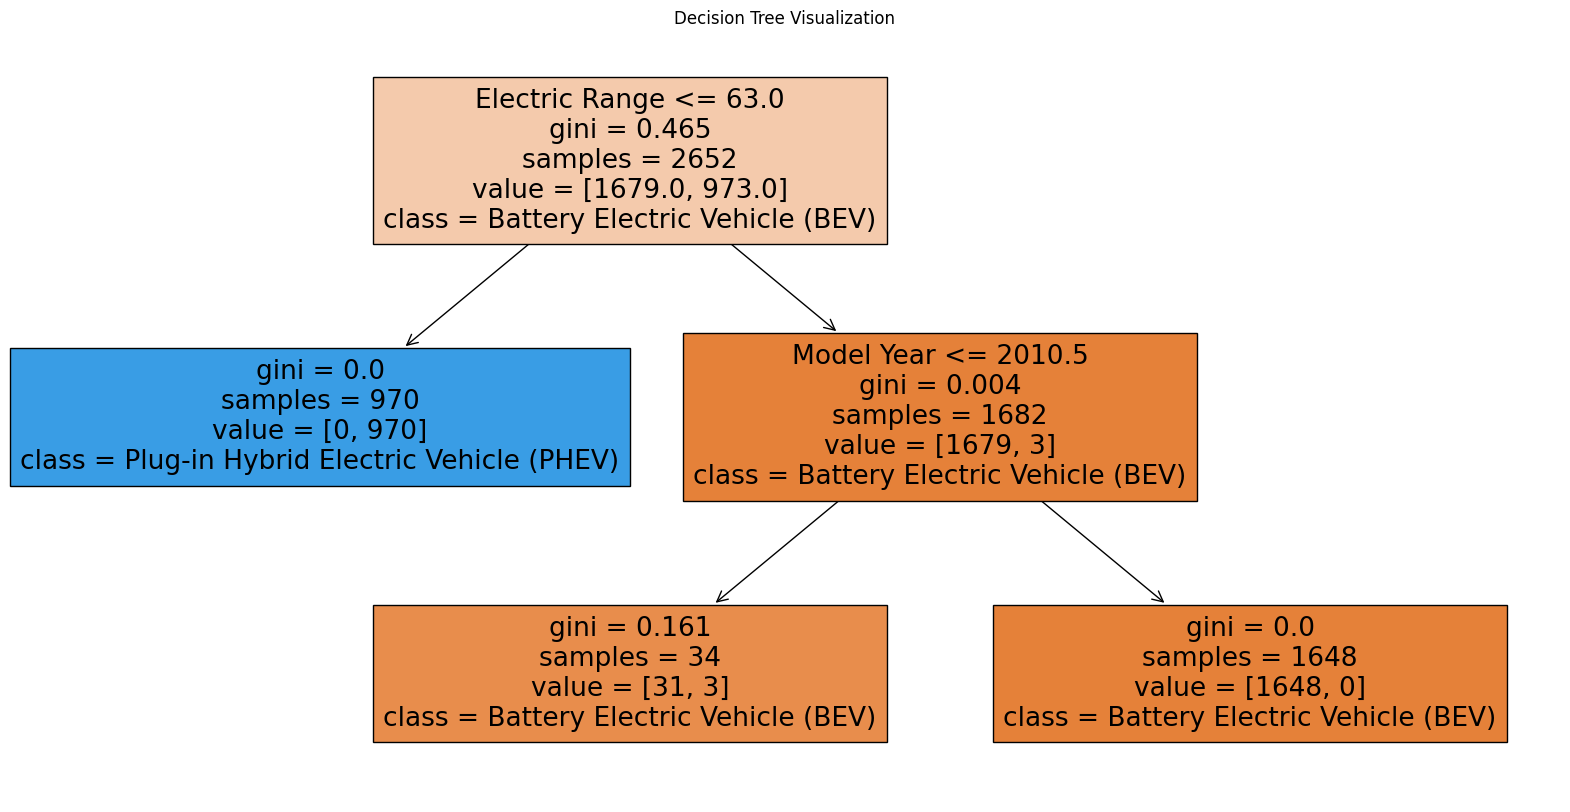

In [10]:
# Step 6: Visualizations for Classification
# Confusion Matrix for Decision Tree
ConfusionMatrixDisplay.from_estimator(clf, X_test_class, y_test_class, cmap='Blues')
plt.title("Confusion Matrix for Decision Tree Classifier")
plt.show()

# ROC Curve for Classification
RocCurveDisplay.from_estimator(clf, X_test_class, y_test_class)
plt.title("ROC Curve for Decision Tree Classifier")
plt.show()

# Feature Importance Plot for Classification
importance = clf.feature_importances_
feature_names = X_class.columns
plt.barh(feature_names, importance, color='teal')
plt.title("Feature Importance in Decision Tree Classifier")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

# Decision Tree Visualization
plt.figure(figsize=(20, 10))
plot_tree(clf, feature_names=feature_names, class_names=clf.classes_, filled=True)
plt.title("Decision Tree Visualization")
plt.show()


Decision Tree Accuracy: 1.00


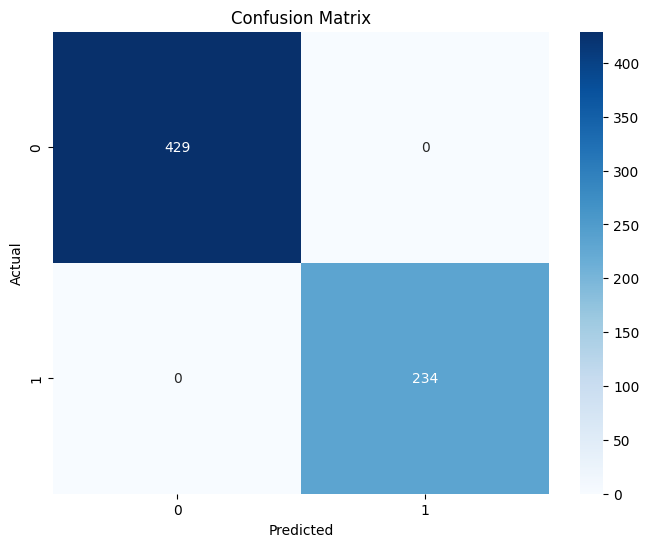

                                        precision    recall  f1-score   support

        Battery Electric Vehicle (BEV)       1.00      1.00      1.00       429
Plug-in Hybrid Electric Vehicle (PHEV)       1.00      1.00      1.00       234

                              accuracy                           1.00       663
                             macro avg       1.00      1.00      1.00       663
                          weighted avg       1.00      1.00      1.00       663



In [11]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate accuracy
accuracy = accuracy_score(y_test_class, y_pred_class)
print(f"Decision Tree Accuracy: {accuracy:.2f}")

# Generate confusion matrix
cm = confusion_matrix(y_test_class, y_pred_class)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Print classification report
print(classification_report(y_test_class, y_pred_class))

Accuracy: 1.00
Precision: 1.00
Recall: 1.00
F1-score: 1.00


<Figure size 1000x800 with 0 Axes>

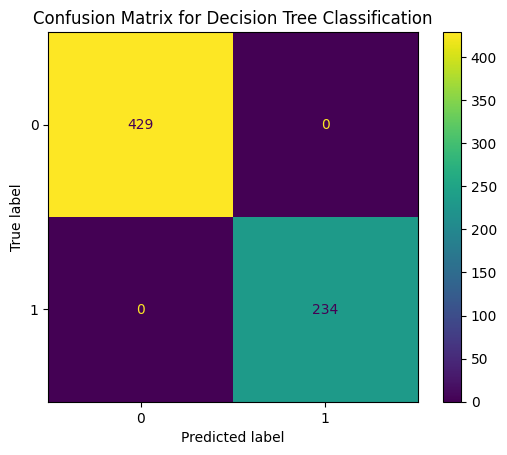

In [13]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Assuming you have already trained your model and made predictions
# y_test: true labels
# y_pred: predicted labels

# Calculate metrics
accuracy = accuracy_score(y_test_class, y_pred_class)
precision = precision_score(y_test_class, y_pred_class, average='weighted')
recall = recall_score(y_test_class, y_pred_class, average='weighted')
f1 = f1_score(y_test_class, y_pred_class, average='weighted')

# Print metrics
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-score: {f1:.2f}")

# Create confusion matrix
cm = confusion_matrix(y_test_class, y_pred_class)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
disp.plot()
plt.title("Confusion Matrix for Decision Tree Classification")
plt.show()

